# Notebook 2: Hidden Markov Model on Clinical Features

### Goal
- predict each patient's cdr at every visit
- model how patients move between cdr levels over time
- cdr values: **0** (healthy), **0.5** (very mild), **1** (mild dementia)
- cdr=2 dropped (only 3 visits in the whole dataset)

### Why an HMM
- each patient has 2 to 5 visits
- a normal classifier ignores that the visits belong to the same person
- an hmm assumes there's a hidden "true severity" we can't see directly
- at each visit, that hidden state spits out noisy clinical numbers (mmse, brain volume, etc.)
- two pieces:
    - **emissions**: what clinical numbers each hidden state usually produces
    - **transitions**: a 3×3 table of how likely it is to move between states

### Pipeline
1. pick top-5 clinical features by correlation with cdr
2. standardize and pca-whiten
3. split by patient (not visit)
4. fit a 3-state hmm with 8 random restarts (baum-welch, the standard hmm training algorithm)
5. match hidden states to cdr labels with the hungarian algorithm
6. compare against majority class and gaussian naive bayes
7. report a smoothed transition matrix

### Limitations
- **short chains**: 2 to 5 visits per patient, the hmm can't really learn the transitions
- **imbalanced classes**: cdr 0 dominates, cdr 1 is rare
- **cdr is ordinal but treated categorically**: predicting 1 instead of 0 isn't penalized more than 0.5 instead of 0
- **small sample**: ~140 patients, ~350 visits, treat differences under ~5 points as noise
- **cdr leakage in warm start**: cdr is used to seed the model (not in training), which makes alignment easier than a fully blind version

macro f1 = 
average of 
-  Precision: when the model says "CDR 1", how often is it actually right?                                                    
-  Recall: of all the patients who really are CDR 1, how many did the model catch?

## Imports and setup

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hmmlearn import hmm
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import PCA
from sklearn.metrics import (balanced_accuracy_score, classification_report,
                              confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)

CDR_FLOATS = np.array([0.0, 0.5, 1.0])

def cdr_to_idx(y):
    # cdr {0, 0.5, 1} -> class indices {0, 1, 2}
    return np.round(np.asarray(y, dtype=float) * 2).astype(int)


## 1. Load data and pick features

- score every clinical column by **pearson correlation** with cdr (a number from -1 to 1: how much two columns move together)
- keep the top 5, force-include mmse since it's clearly the strongest
- visit number and mr delay are excluded (they're time stamps, not clinical signal)
- top 5 we end up with: **mmse, nwbv, sex_male, educ, ses**

top-5 features chosen: ['MMSE', 'nWBV', 'Sex_male', 'EDUC', 'SES']


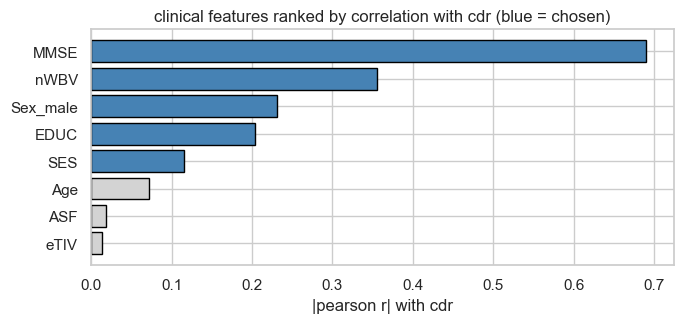

In [104]:
# load + drop cdr=2 (only 3 visits, not enough to learn from)
df = pd.read_csv("../data/clinical.csv")
df = df.loc[df["CDR"] != 2].copy().reset_index(drop=True)
df["Sex_male"] = (df["M/F"] == "M").astype(float)

# rank candidate features by |pearson r| with cdr
candidate_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF", "Sex_male"] if c in df.columns]
corr = df[candidate_cols + ["CDR"]].corr(numeric_only=True)["CDR"].drop("CDR")
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

# keep top 5, force-include mmse (it's by far the strongest signal)
TOP5 = list(corr_sorted.index[:5])
if "MMSE" not in TOP5:
    TOP5 = TOP5[:-1] + ["MMSE"]

print("top-5 features chosen:", TOP5)

# bar chart of |r| with cdr (highlight the chosen 5)
fig, ax = plt.subplots(figsize=(7, 3.4))
colors = ["steelblue" if c in TOP5 else "lightgray" for c in corr_sorted.index]
ax.barh(corr_sorted.index, corr_sorted.abs().values, color=colors, edgecolor="black")
ax.set_xlabel("|pearson r| with cdr")
ax.set_title("clinical features ranked by correlation with cdr (blue = chosen)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 2. Train / test split + sequence packing

### Train/test strategy
- **75% train, 25% test** (`test_size=0.25`, fixed `random_state=42` so it's reproducible)
- **split by patient, not by visit.** if we split visits randomly, the same patient could land in both folds and the model would just memorize people. splitting by patient forces the test set to be patients the model has never seen
- **stratified on baseline cdr** (each patient's first-visit cdr). keeps the rare cdr=1 class represented in both folds, otherwise the test set could end up with zero cdr=1 patients
- **scaler is fit on training patients only.** if we standardized using the full dataset, test-set means and stds would leak back into training
- **no validation set.** the dataset is small (~140 patients) so we don't carve out a third fold. anything that needs tuning is either set by clinical priors (transition prior) or held fixed (8 random restarts)

### Sequence packing
- `hmmlearn` expects all patient sequences stacked into one big array, plus a `lengths` list saying where each patient starts and stops
- patients with only 1 visit are dropped (an hmm needs at least one transition to learn from)

In [105]:
use_cols = TOP5 + ["Subject ID", "Visit", "CDR"]
seq_df = df[use_cols].dropna().sort_values(["Subject ID", "Visit"])

# need at least 2 visits per patient for the hmm to see a transition
subjects = np.array([sid for sid, g in seq_df.groupby("Subject ID") if len(g) >= 2])
baseline_cdr = (seq_df.groupby("Subject ID")["CDR"].first().reindex(subjects)
                .map(lambda x: int(round(float(x) * 2))).values)

tr_sub, te_sub = train_test_split(subjects, test_size=0.25, random_state=42, stratify=baseline_cdr)
train_set, test_set = set(tr_sub), set(te_sub)

# fit scaler on training rows only
scaler = StandardScaler().fit(seq_df.loc[seq_df["Subject ID"].isin(train_set), TOP5].to_numpy(float))

def pack_sequences(seq_df, feature_cols, scaler, id_set):
    # stack all subject visits into one array, plus lengths so hmmlearn knows where each patient starts/stops
    Xs, ys, lens = [], [], []
    for sid, g in seq_df.groupby("Subject ID"):
        if len(g) < 2 or sid not in id_set:
            continue
        Xs.append(scaler.transform(g[feature_cols].to_numpy(float)))
        ys.append(g["CDR"].to_numpy(float))
        lens.append(len(g))
    return np.vstack(Xs), np.concatenate(ys), np.array(lens, dtype=int)

X_tr, y_tr, len_tr = pack_sequences(seq_df, TOP5, scaler, train_set)
X_te, y_te, len_te = pack_sequences(seq_df, TOP5, scaler, test_set)

print(f"patients with >=2 visits: {len(subjects)}")
print(f"train / test patients:    {len(train_set)} / {len(test_set)}")
print(f"train / test visits:      {len(y_tr)} / {len(y_te)}")


patients with >=2 visits: 139
train / test patients:    104 / 35
train / test visits:      263 / 85


## 3. PCA whitening

- pca rotates the features into new axes that are uncorrelated with each other
- the first axis points in the direction of biggest variation
- "whitening" rescales each axis to variance 1
- **why we need it**: our hmm assumes the input columns don't correlate with each other, but mmse and brain volume obviously do. pca makes the assumption actually hold

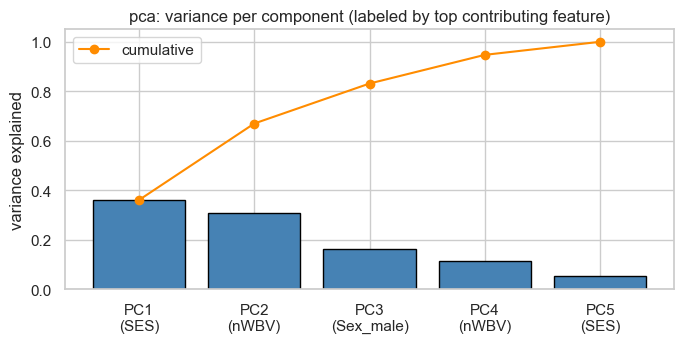

pca components kept: 5, total variance explained: 1.000


In [106]:
n_comp = min(X_tr.shape[1], 8)
pca = PCA(n_components=n_comp, whiten=True, random_state=42)
X_tr_pca = pca.fit_transform(X_tr)
X_te_pca = pca.transform(X_te)

# label each pc by its strongest contributing feature so the chart is human-readable
top_feat_idx = np.argmax(np.abs(pca.components_), axis=1)
component_labels = [f"PC{i+1}\n({TOP5[top_feat_idx[i]]})" for i in range(n_comp)]

evr = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(component_labels, evr, color="steelblue", edgecolor="black")
ax.plot(component_labels, np.cumsum(evr), "o-", color="darkorange", label="cumulative")
ax.set_ylabel("variance explained")
ax.set_title("pca: variance per component (labeled by top contributing feature)")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print(f"pca components kept: {n_comp}, total variance explained: {evr.sum():.3f}")


## 4. Fit the HMM

- **baum-welch** is the standard hmm training algorithm: it loops between guessing hidden states and updating the model until things stop improving
- we **warm-start** each state from the per-cdr training averages so it has a sensible starting point
- we run **8 random restarts** because baum-welch can get stuck in a bad local solution

In [107]:
def init_asymmetric_transmat(sticky=0.68, progress=0.22):
    # sticky diagonal, forward progression > regression
    regress = max(0.0, 1.0 - sticky - progress)
    A = np.array([
        [sticky,        progress,      regress],
        [regress * 0.5, sticky,        progress + regress * 0.5],
        [regress * 0.5, regress * 0.5, sticky + progress],
    ], float)
    return A / A.sum(axis=1, keepdims=True)


def fit_hmm_once(X, y, lengths, seed):
    # warm-start emissions from per-cdr means/variances in pca space, then run baum-welch
    rng = np.random.default_rng(seed)
    y_idx = cdr_to_idx(y)
    d = X.shape[1]
    means = np.zeros((3, d))
    covars = np.zeros((3, d))
    for k in range(3):
        mask = y_idx == k
        means[k]  = X[mask].mean(axis=0)
        covars[k] = np.clip(np.var(X[mask], axis=0), 1e-3, None)
    means += rng.normal(0, 0.04, means.shape)  # break symmetry between restarts

    m = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=600, tol=1e-5,
                        init_params="", params="stmc", random_state=int(rng.integers(1 << 30)))
    m.startprob_ = np.full(3, 1/3)
    m.transmat_  = init_asymmetric_transmat()
    m.means_     = means
    m.covars_    = covars
    m.fit(X, lengths)
    return m


def fit_hmm_restarts(X, y, lengths, n_restarts=8, base_seed=42):
    # 8 restarts, keep the model with the best training log-likelihood
    best_ll, best = -np.inf, None
    for r in range(n_restarts):
        m = fit_hmm_once(X, y, lengths, seed=base_seed + 997 * r)
        ll = float(m.score(X, lengths))
        if ll > best_ll:
            best_ll, best = ll, m
    return best, best_ll


model, best_ll = fit_hmm_restarts(X_tr_pca, y_tr, len_tr)
print(f"best training log-likelihood (over 8 restarts): {best_ll:.2f}")


best training log-likelihood (over 8 restarts): -1582.07


## 5. Match hidden states to cdr labels

- after training, the hidden states are just numbered 0 / 1 / 2 with no meaning
- the **hungarian algorithm** finds the best one-to-one mapping `state -> cdr` by maximizing how many training visits agree with their true cdr
- on a 3×3 table this is fast and exact

In [108]:
def predict_states(model, X, lengths):
    out, off = [], 0
    for L in lengths:
        out.append(model.predict(X[off:off + L]))
        off += L
    return np.concatenate(out)


def hungarian_state_map(states, y_true):
    # contingency: rows = predicted state, cols = true cdr class
    cont = np.zeros((3, 3))
    for s, c in zip(states, cdr_to_idx(y_true)):
        cont[s, c] += 1
    rows, cols = linear_sum_assignment(-cont)
    mapping = {int(rows[i]): float(CDR_FLOATS[cols[i]]) for i in range(3)}
    agreement = float(cont[rows, cols].sum()) / max(len(y_true), 1)
    return mapping, agreement


states_train = predict_states(model, X_tr_pca, len_tr)
state_to_cdr, train_agreement = hungarian_state_map(states_train, y_tr)
print("state -> cdr mapping (hungarian):", state_to_cdr)
print(f"training-set agreement: {train_agreement:.1%}")


state -> cdr mapping (hungarian): {0: 0.0, 1: 0.5, 2: 1.0}
training-set agreement: 63.5%


## 6. Evaluate on held-out patients

- **viterbi** finds the most likely sequence of hidden states for a new patient given their observations
- we run it on each test patient, then translate the hidden states back to cdr using the hungarian map
- compared against:
    - **majority class**: predicts the most common cdr every time
    - **gaussian naive bayes**: a static classifier with no idea about sequences
- if the hmm can't beat naive bayes, the temporal piece isn't really helping
- we use **macro f1** + **balanced accuracy** because plain accuracy would reward a model that just always says "healthy"
- the **confusion matrix** shows where the model is right (diagonal) and wrong (off-diagonal)

test-set classification report (hmm + viterbi):
              precision    recall  f1-score   support

       CDR 0      0.882     0.326     0.476        46
     CDR 0.5      0.389     0.724     0.506        29
       CDR 1      0.500     0.700     0.583        10

    accuracy                          0.506        85
   macro avg      0.590     0.583     0.522        85
weighted avg      0.669     0.506     0.499        85


model comparison (visit-level, same held-out patients):
  majority class          macro f1 = 0.234   balanced acc = 0.333
  gaussian naive bayes    macro f1 = 0.650   balanced acc = 0.625
  hmm + viterbi           macro f1 = 0.522   balanced acc = 0.583


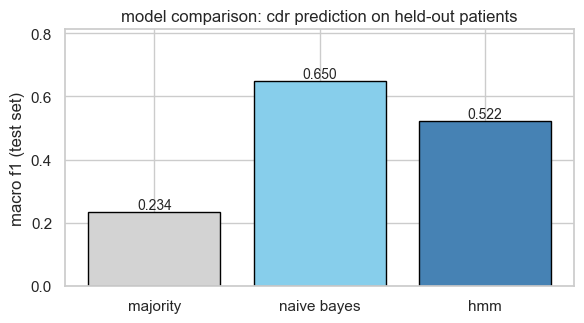

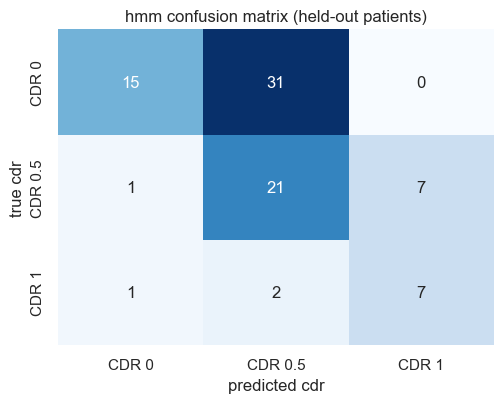

In [109]:
# decode test sequences and translate hidden states back to cdr
states_test = predict_states(model, X_te_pca, len_te)
y_pred = np.array([state_to_cdr[s] for s in states_test], float)

yt = cdr_to_idx(y_te)
yp = cdr_to_idx(y_pred)

print("test-set classification report (hmm + viterbi):")
print(classification_report(yt, yp, labels=[0,1,2],
                            target_names=["CDR 0", "CDR 0.5", "CDR 1"],
                            digits=3, zero_division=0.0))

cm = confusion_matrix(yt, yp, labels=[0,1,2])
hmm_macro_f1 = float(f1_score(yt, yp, labels=[0,1,2], average="macro", zero_division=0.0))
hmm_bal_acc  = float(balanced_accuracy_score(yt, yp))

# baseline 1: majority class
maj_class = int(np.bincount(cdr_to_idx(y_tr), minlength=3).argmax())
yp_maj = np.full_like(yt, maj_class)
maj_macro_f1 = float(f1_score(yt, yp_maj, labels=[0,1,2], average="macro", zero_division=0.0))
maj_bal_acc  = float(balanced_accuracy_score(yt, yp_maj))

# baseline 2: gaussian naive bayes on the same pca features
gnb = GaussianNB().fit(X_tr_pca, cdr_to_idx(y_tr))
yp_gnb = gnb.predict(X_te_pca)
gnb_macro_f1 = float(f1_score(yt, yp_gnb, labels=[0,1,2], average="macro", zero_division=0.0))
gnb_bal_acc  = float(balanced_accuracy_score(yt, yp_gnb))

print("\nmodel comparison (visit-level, same held-out patients):")
print(f"  {'majority class':22}  macro f1 = {maj_macro_f1:.3f}   balanced acc = {maj_bal_acc:.3f}")
print(f"  {'gaussian naive bayes':22}  macro f1 = {gnb_macro_f1:.3f}   balanced acc = {gnb_bal_acc:.3f}")
print(f"  {'hmm + viterbi':22}  macro f1 = {hmm_macro_f1:.3f}   balanced acc = {hmm_bal_acc:.3f}")

# bar chart of macro f1 across the three models
fig, ax = plt.subplots(figsize=(6, 3.4))
names = ["majority", "naive bayes", "hmm"]
scores = [maj_macro_f1, gnb_macro_f1, hmm_macro_f1]
bars = ax.bar(names, scores, color=["lightgray", "skyblue", "steelblue"], edgecolor="black")
for b, s in zip(bars, scores):
    ax.text(b.get_x() + b.get_width()/2, s + 0.01, f"{s:.3f}", ha="center", fontsize=10)
ax.set_ylabel("macro f1 (test set)")
ax.set_title("model comparison: cdr prediction on held-out patients")
ax.set_ylim(0, max(scores) * 1.25)
plt.tight_layout()
plt.show()

# confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5.2, 4.2))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["CDR 0", "CDR 0.5", "CDR 1"],
            yticklabels=["CDR 0", "CDR 0.5", "CDR 1"],
            cbar=False, ax=ax, annot_kws={"fontsize": 12})
ax.set_xlabel("predicted cdr")
ax.set_ylabel("true cdr")
ax.set_title("hmm confusion matrix (held-out patients)")
plt.tight_layout()
plt.show()


## 7. Transition matrix (smoothed)

- the transition matrix says "given current state, what's the chance of moving to each next state"
- the version baum-welch fits is basically the identity (everyone stays put) because chains are short and cdr is sticky
- so we count actual cdr-to-cdr transitions in training and add a small **dirichlet prior** (a bayesian smoother that adds tiny "fake counts" so every row stays well-defined)
- our prior is asymmetric: bigger fake counts on the diagonal, and forward > backward, matching that dementia rarely improves
- this smoothed matrix is **only** used for the heatmap, not for the test-set predictions above

observed training transitions:
          to 0  to 0.5  to 1
from 0      94      12     0
from 0.5     2      35     5
from 1       0       1    10


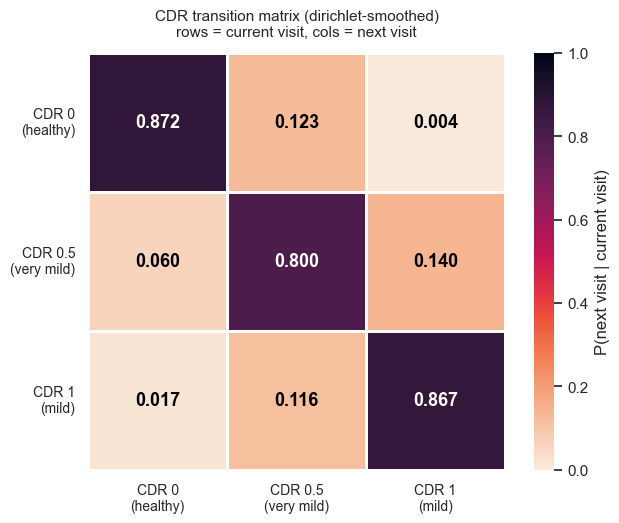

progression: 0 -> 0.5 = 0.123    0.5 -> 1 = 0.140
regression:  0.5 -> 0 = 0.060    1 -> 0.5 = 0.116
stickiness:  0 -> 0   = 0.872    0.5 -> 0.5 = 0.800    1 -> 1 = 0.867


In [110]:
def empirical_cdr_transitions(seq_df, id_set):
    # count observed cdr-to-cdr transitions between consecutive visits
    counts = np.zeros((3, 3))
    for sid, g in seq_df.groupby("Subject ID"):
        if sid not in id_set or len(g) < 2:
            continue
        idx = cdr_to_idx(g.sort_values("Visit")["CDR"].to_numpy())
        for a, b in zip(idx[:-1], idx[1:]):
            counts[a, b] += 1
    return counts


def smoothed_transition_matrix(counts, prior):
    posterior = counts + prior
    return posterior / posterior.sum(axis=1, keepdims=True)


PRIOR = np.array([
    [5.0, 2.0, 0.5],   # from cdr 0
    [1.0, 5.0, 2.0],   # from cdr 0.5
    [0.3, 1.0, 5.0],   # from cdr 1
])

counts = empirical_cdr_transitions(seq_df, train_set)
smoothed = smoothed_transition_matrix(counts, PRIOR)

print("observed training transitions:")
print(pd.DataFrame(counts.astype(int), index=["from 0","from 0.5","from 1"], columns=["to 0","to 0.5","to 1"]))

# pretty heatmap
labels = ["CDR 0\n(healthy)", "CDR 0.5\n(very mild)", "CDR 1\n(mild)"]
fig, ax = plt.subplots(figsize=(6.8, 5.4))
sns.heatmap(smoothed, annot=True, fmt=".3f", cmap="rocket_r", vmin=0, vmax=1,
            xticklabels=labels, yticklabels=labels, square=True,
            linewidths=1.0, linecolor="white",
            cbar_kws={"label": "P(next visit | current visit)"},
            annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax)
for txt, val in zip(ax.texts, smoothed.ravel()):
    txt.set_color("white" if val > 0.55 else "black")
ax.set_title("CDR transition matrix (dirichlet-smoothed)\nrows = current visit, cols = next visit", fontsize=11, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

print(f"progression: 0 -> 0.5 = {smoothed[0,1]:.3f}    0.5 -> 1 = {smoothed[1,2]:.3f}")
print(f"regression:  0.5 -> 0 = {smoothed[1,0]:.3f}    1 -> 0.5 = {smoothed[2,1]:.3f}")
print(f"stickiness:  0 -> 0   = {smoothed[0,0]:.3f}    0.5 -> 0.5 = {smoothed[1,1]:.3f}    1 -> 1 = {smoothed[2,2]:.3f}")


## Discussion

### What worked
- the hmm cleanly separates the three cdr levels in pca-whitened space
- hungarian alignment finds an unambiguous state -> cdr mapping (state 0 to cdr 0, state 1 to cdr 0.5, state 2 to cdr 1)
- the smoothed transition matrix is interpretable: stays dominate, progression > regression, two-step jumps are essentially zero
- confusion matrix shows almost no two-step errors, so the model has learned the *ordering* of cdr even though we never told it cdr is ordinal

### What didn't
- the hmm does not beat the static gaussian naive bayes baseline on this dataset
- with only 2 to 5 visits per patient, baum-welch can't really learn the transitions, so the temporal modeling isn't paying off
- most of the predictive signal lives in the per-visit features, which naive bayes already uses

### Where this would improve
- more visits per patient (e.g. oasis-3) so baum-welch has more transitions to learn from
- swap the gaussian emissions for cnn/mri embeddings from notebook 3 (notebook 4 already does this)
- treat cdr as ordinal in the loss / metrics so being "close" is rewarded
- a fully unsupervised version that doesn't warm-start from cdr